[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Chapters/chapter_12/chapter_12_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 12 — Unsupervised Learning
## Lab: PCA, K-means, hierarchical clustering

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

> **Companion notebook to Lecture 14 — ISLP Chapter 12.**
> Work through §1–§5 alongside the slides, then use the closing section, *Lecture exercises — worked
> Python solutions*, which answers every `[Python]`-tagged exercise from the deck.
> Every number printed here reproduces a number quoted on a slide: same data, same seeds,
> same `n_init`. Where a cell re-creates a slide figure, the markdown says so.

**Goal.** Run PCA on `USArrests` and show what standardising does to it; cluster with $K$-means and
expose its local optima; build and cut dendrograms under four linkages; cluster a $1000\times40$
gene-expression matrix under two dissimilarities; and watch all of it find clusters in pure noise.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

## 1. PCA on USArrests

Four crime and urbanisation measures for the 50 US states. `load()` finds `USArrests` through
statsmodels' copy of the R datasets, falling back to `ALL CSV FILES - 2nd Edition/USArrests.csv`.

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

USA = load('USArrests', index_col=0)          # 50 states x 4 features
print(USA.shape)
print(USA.head(3).round(1))
print('\nraw variances:', USA.var().round(1).to_dict())   # Assault dwarfs the rest
print('Assault / Murder variance ratio:', round(USA.var()['Assault'] / USA.var()['Murder'], 1))

(50, 4)
          Murder  Assault  UrbanPop  Rape
rownames                                 
Alabama     13.2      236        58  21.2
Alaska      10.0      263        48  44.5
Arizona      8.1      294        80  31.0

raw variances: {'Murder': 19.0, 'Assault': 6945.2, 'UrbanPop': 209.5, 'Rape': 87.7}
Assault / Murder variance ratio: 366.1


**Reading the output.** `Assault` carries $6945.2$ units of variance against `Murder`'s $19.0$ — a
factor of **366**, purely because assaults are about 22 times more common than murders. PCA
maximises variance, so this ratio is not a detail: it decides the answer. The deck quotes both
numbers on *Scaling is not optional*.

In [3]:
Xs  = StandardScaler().fit_transform(USA)     # each column: mean 0, variance 1
pca = PCA().fit(Xs)

print('PVE       ', np.round(pca.explained_variance_ratio_, 4))
print('cumulative', np.round(np.cumsum(pca.explained_variance_ratio_), 4))
print('eigenvalues of the correlation matrix',
      np.round(np.linalg.eigvalsh(USA.corr().values)[::-1], 4),
      ' sum =', round(np.linalg.eigvalsh(USA.corr().values).sum(), 3))

loadings = pd.DataFrame(pca.components_.T, index=USA.columns,
                        columns=[f'PC{i+1}' for i in range(USA.shape[1])])
loadings.round(3)

PVE        [0.6201 0.2474 0.0891 0.0434]
cumulative [0.6201 0.8675 0.9566 1.    ]
eigenvalues of the correlation matrix [2.4802 0.9898 0.3566 0.1734]  sum = 4.0


,PC1,PC2,PC3,PC4
Murder,0.536,-0.418,-0.341,-0.649
Assault,0.583,-0.188,-0.268,0.743
UrbanPop,0.278,0.873,-0.378,-0.134
Rape,0.543,0.167,0.818,-0.089


**Reading the output.** PVE $=(0.6201,\,0.2474,\,0.0891,\,0.0434)$, so two components carry
$86.8\%$ — exactly the figures on the scree-plot slide. The eigenvalues
$(2.480,\,0.990,\,0.357,\,0.173)$ sum to $4=p$, as they must for standardised data; these are the
$\lambda_m$ in the deck's loadings table. (`pca.explained_variance_` divides by $n-1$ while
`StandardScaler` divides by $n$, so it reports $50/49$ times these values — the ratios, and hence
the PVEs, are identical.) PC1 loads on Murder $0.536$, Assault $0.583$, Rape $0.543$ and UrbanPop
only $0.278$: an overall *serious-crime rate*. PC2 is almost all UrbanPop ($0.873$).

**Signs.** `scikit-learn` returns PC2 as $(-0.418,-0.188,0.873,0.167)$; ISLP Figure 12.1 prints the
negatives of those. Both are correct — a loading vector and its negative describe the same
direction. Do not "fix" it.

### Scaling is not optional: the same PCA without standardising

In [4]:
Xc  = (USA - USA.mean()).values               # centred, but NOT scaled
pcu = PCA().fit(Xc)

for tag, p in [('scaled  ', pca), ('unscaled', pcu)]:
    print(tag, 'PVE', np.round(p.explained_variance_ratio_, 4),
          ' PC1', pd.Series(p.components_[0].round(3), index=USA.columns).to_dict())

scaled   PVE [0.6201 0.2474 0.0891 0.0434]  PC1 {'Murder': 0.536, 'Assault': 0.583, 'UrbanPop': 0.278, 'Rape': 0.543}
unscaled PVE [9.655e-01 2.780e-02 5.800e-03 8.000e-04]  PC1 {'Murder': 0.042, 'Assault': 0.995, 'UrbanPop': 0.046, 'Rape': 0.075}


**Reading the output.** Unscaled, PC1 takes $96.6\%$ of the variance and its loading vector is
$(0.042,\,0.995,\,0.046,\,0.075)$ — it *is* `Assault`, with rounding attached; PC2 is `UrbanPop`.
The two panels of the deck's scaled-vs-unscaled figure show exactly this. Report the standardised
analysis and say so in the methods section: the unscaled version is a statement about measurement
units, not about crime.

### Biplot

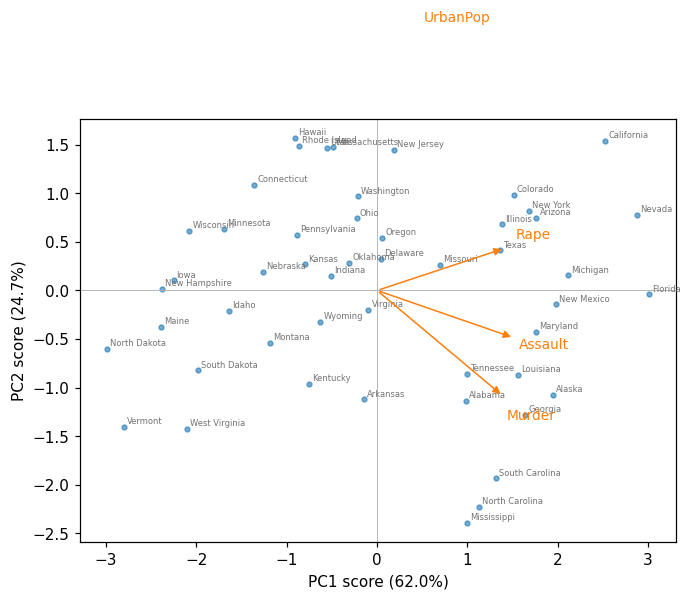

In [5]:
Z = pca.transform(Xs)                          # scores
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.6)
for i, name in enumerate(USA.index):
    ax.annotate(name, (Z[i, 0], Z[i, 1]), fontsize=5.5, color='0.45',
                xytext=(2, 2), textcoords='offset points')
for j, var in enumerate(USA.columns):          # loading arrows, scaled up to be visible
    dx, dy = 2.6 * pca.components_[0, j], 2.6 * pca.components_[1, j]
    ax.annotate('', xy=(dx, dy), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='C1'))
    ax.text(dx * 1.22, dy * 1.22, var, color='C1', fontsize=9, ha='center')
ax.axhline(0, color='0.7', lw=0.6); ax.axvline(0, color='0.7', lw=0.6)
ax.set(xlabel='PC1 score (62.0%)', ylabel='PC2 score (24.7%)')
plt.show()

**How to read the biplot.** Points are states in the plane of the first two scores; arrows are the
loadings. Angles between arrows approximate correlations (UrbanPop and Murder are nearly
perpendicular, $r=0.07$). Florida sits furthest right (PC1 $=3.01$), North Dakota furthest left
($-2.99$); Hawaii and California are high on PC2 (urban), Mississippi lowest ($-2.39$). Remember
that $13.2\%$ of the variation is not in this picture at all.

### Scree plot and cumulative PVE

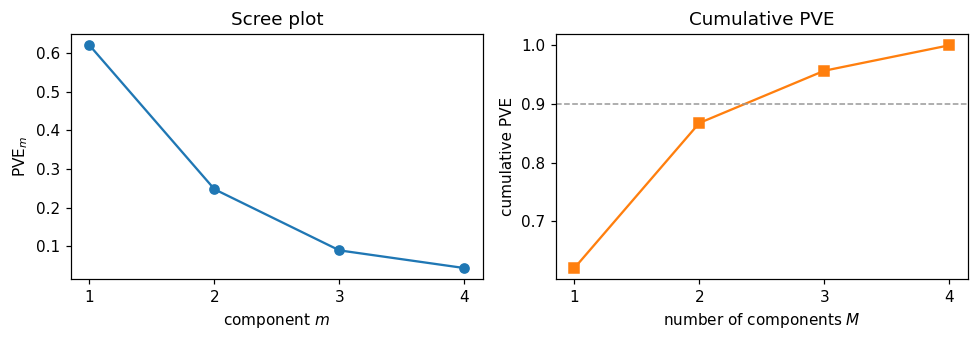

In [6]:
pve = pca.explained_variance_ratio_
k = np.arange(1, len(pve) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax1.plot(k, pve, 'o-')
ax1.set(xlabel='component $m$', ylabel='PVE$_m$', xticks=k, title='Scree plot')
ax2.plot(k, np.cumsum(pve), 's-', color='C1')
ax2.axhline(0.9, color='0.6', ls='--', lw=1)
ax2.set(xlabel='number of components $M$', ylabel='cumulative PVE', xticks=k,
        title='Cumulative PVE')
plt.tight_layout(); plt.show()

**Reading the output.** The elbow at $m=2$ is a kink in a curve, not a test: $M=2$ ($86.8\%$) and
$M=3$ ($95.7\%$) are both defensible, and nothing held out of the data can decide between them.

## 2. K-means

In [7]:
from sklearn.cluster import KMeans

for K in (1, 2, 3, 4):
    km = KMeans(n_clusters=K, n_init=50, random_state=0).fit(Xs)
    print(f'K={K}  W={km.inertia_:7.3f}  sizes={np.bincount(km.labels_).tolist()}'
          f'  1 - W/TSS={1 - km.inertia_ / 200:.3f}')

K=1  W=200.000  sizes=[50]  1 - W/TSS=0.000
K=2  W=104.962  sizes=[20, 30]  1 - W/TSS=0.475
K=3  W= 79.922  sizes=[17, 20, 13]  1 - W/TSS=0.600
K=4  W= 57.554  sizes=[13, 8, 16, 13]  1 - W/TSS=0.712


**Reading the output.** The total sum of squares of the standardised matrix is exactly
$n\times p = 50\times4 = 200$, so the "variance explained" numbers are easy to read: $W$ falls
$200 \to 105.0 \to 79.9 \to 57.6$, i.e. $47\%$, $60\%$, $71\%$. It keeps falling all the way to $0$
at $K=50$, so this sequence contains no evidence about which $K$ is right.

In [8]:
km3 = KMeans(n_clusters=3, n_init=50, random_state=0).fit(Xs)
profiles = USA.assign(cluster=km3.labels_).groupby('cluster').mean().round(1)
profiles['n'] = np.bincount(km3.labels_)
print(profiles)
print('\noverall mean:', USA.mean().round(1).to_dict())

         Murder  Assault  UrbanPop  Rape   n
cluster                                     
0           5.8    141.9      72.5  18.8  17
1          12.2    255.2      68.4  29.2  20
2           3.6     78.5      52.1  12.2  13

overall mean: {'Murder': 7.8, 'Assault': 170.8, 'UrbanPop': 65.5, 'Rape': 21.2}


**Reading the output.** Cluster means in the **original units** are how a clustering earns its
keep: a high-crime urban group ($n=20$: Murder 12.2, Assault 255.2), a moderate, most-urban group
($n=17$) and a low-crime rural group ($n=13$: Murder 3.6, Assault 78.5, UrbanPop 52.1). That is
interpretability, not validation — three groups strung along one crime axis is also what $K$-means
would return from a single unimodal cloud.

### The local-optimum problem, in two runs

This reproduces the deck's two-panel figure: same data, same $K$, one random start each.

In [9]:
for seed in (1, 18):
    km = KMeans(n_clusters=4, n_init=1, random_state=seed).fit(Xs)
    print(f'random_state={seed:2d}  n_init=1  W={km.inertia_:.3f}  '
          f'sizes={np.bincount(km.labels_, minlength=4).tolist()}')
print('n_init=50           W=%.3f' % KMeans(n_clusters=4, n_init=50, random_state=0)
      .fit(Xs).inertia_)
# and what scikit-learn does if you say nothing at all:
print('library default     W=%.3f' % KMeans(n_clusters=4, random_state=0).fit(Xs).inertia_)

random_state= 1  n_init=1  W=57.554  sizes=[16, 8, 13, 13]
random_state=18  n_init=1  W=77.856  sizes=[8, 28, 13, 1]
n_init=50           W=57.554
library default     W=58.242


**Reading the output.** Seed 1 reaches $W=57.554$; seed 18 stops at $W=77.856$ with a
singleton cluster, $35\%$ worse — and reports nothing unusual. Both are converged: no single
observation wants to move.

Note the last line. Since scikit-learn 1.4 the default is `n_init='auto'`, which with the default
`k-means++` initialisation means **one start**, so the library default returns $W=58.242$ rather
than the optimum $57.554$. Set `n_init` explicitly, every time.

## 3. Hierarchical clustering

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score

trees = {m: linkage(Xs, method=m) for m in ('complete', 'average', 'single', 'centroid', 'ward')}
cut3  = {m: fcluster(Zl, 3, criterion='maxclust') for m, Zl in trees.items()}

for m, Zl in trees.items():
    s2 = str(np.bincount(fcluster(Zl, 2, 'maxclust'))[1:].tolist())
    s3 = str(np.bincount(cut3[m])[1:].tolist())
    print(f'{m:9s} k=2 {s2:<12} k=3 {s3:<14} tallest fusion {Zl[-1, 2]:6.2f} '
          f'ARI vs complete {adjusted_rand_score(cut3["complete"], cut3[m]):.3f}')
print('\nK-means (K=3) vs complete linkage, ARI:',
      round(adjusted_rand_score(cut3['complete'], km3.labels_), 3))

complete  k=2 [31, 19]     k=3 [31, 11, 8]    tallest fusion   6.14 ARI vs complete 1.000
average   k=2 [30, 20]     k=3 [30, 19, 1]    tallest fusion   3.36 ARI vs complete 0.784
single    k=2 [49, 1]      k=3 [48, 1, 1]     tallest fusion   2.08 ARI vs complete 0.079
centroid  k=2 [30, 20]     k=3 [30, 19, 1]    tallest fusion   2.81 ARI vs complete 0.784
ward      k=2 [19, 31]     k=3 [19, 12, 19]   tallest fusion  13.65 ARI vs complete 0.465

K-means (K=3) vs complete linkage, ARI: 0.394


**Reading the output.** These are the numbers in the deck's linkage table. Complete linkage cuts
into $(31,11,8)$; average and centroid agree with each other exactly and with complete at ARI
$0.784$; Ward gives $(19,12,19)$; and **single linkage returns $(48,1,1)$** — it peels off Alaska
and Florida and calls the other 48 states one cluster, agreeing with complete at ARI $0.079$,
i.e. essentially not at all. Five defensible methods, five different partitions, and nothing in
the data ranks them.

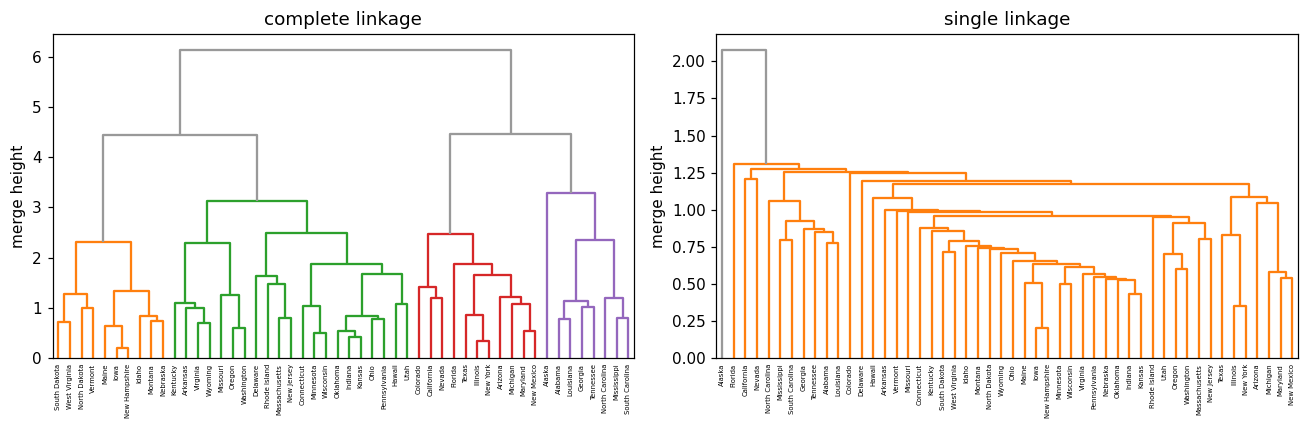

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, m in zip(axes, ('complete', 'single')):
    dendrogram(trees[m], labels=USA.index.tolist(), leaf_font_size=4.5, ax=ax,
               color_threshold=0.7 * trees[m][-1, 2], above_threshold_color='0.6')
    ax.set(title=f'{m} linkage', ylabel='merge height')
    ax.tick_params(axis='x', length=0)
plt.tight_layout(); plt.show()

**How to read a dendrogram.** Only the **height** at which two branches first join carries
information. Horizontal position does not: in the complete-linkage tree Alaska is drawn right next
to Alabama, but they only fuse at height $3.29$, while Alabama and Louisiana fuse at $0.78$ and
Alabama and Iowa not until $6.14$. The cell below checks those three numbers directly.

In [12]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import squareform

heights = pd.DataFrame(squareform(cophenet(trees['complete'])),
                       index=USA.index, columns=USA.index)
for a, b in [('Alabama', 'Alaska'), ('Alabama', 'Louisiana'), ('Alabama', 'Iowa')]:
    print(f'{a} - {b}: first fuse at height {heights.loc[a, b]:.2f}')

Alabama - Alaska: first fuse at height 3.29
Alabama - Louisiana: first fuse at height 0.78
Alabama - Iowa: first fuse at height 6.14


**Reading the output.** Adjacency lied; the heights did not. Cutting the complete-linkage tree at
$4.9$ gives 2 clusters of sizes $(31,19)$ and at $4.2$ gives 3 of sizes $(31,11,8)$ — the cut
height is a choice you make *after* seeing the tree, and no $p$-value corrects for it.

## 4. High-dimensional data: gene expression (and optional NCI60)

`Ch12Ex13.csv` holds 1000 genes (rows) on 40 tissue samples (columns): the first 20 are healthy,
the last 20 diseased. The labels are used **only to score** the clusterings afterwards.

In [13]:
G = load('Ch12Ex13', header=None).values      # 1000 genes x 40 samples
X = G.T                                       # cluster the SAMPLES: 40 x 1000
truth = np.array([0] * 20 + [1] * 20)         # scoring only, never fitting
print('gene matrix', G.shape, ' sample matrix', X.shape)

Dcorr = 1 - np.corrcoef(X)                    # correlation-based dissimilarity
for nm, arg in [('euclidean', X), ('1 - r    ', squareform(Dcorr, checks=False))]:
    for m in ('complete', 'average', 'single'):
        lab = fcluster(linkage(arg, method=m), 2, criterion='maxclust')
        sz = str(np.bincount(lab)[1:].tolist())
        print(f'{nm}  {m:9s} sizes {sz:<10} '
              f'ARI vs truth {adjusted_rand_score(truth, lab):.3f}')

gene matrix (1000, 40)  sample matrix (40, 1000)
euclidean  complete  sizes [20, 20]   ARI vs truth 1.000
euclidean  average   sizes [20, 20]   ARI vs truth 1.000
euclidean  single    sizes [20, 20]   ARI vs truth 1.000
1 - r      complete  sizes [30, 10]   ARI vs truth 0.235
1 - r      average   sizes [31, 9]    ARI vs truth 0.188
1 - r      single    sizes [39, 1]    ARI vs truth 0.000


**Reading the output.** Under **Euclidean** distance all three linkages recover the two groups
perfectly ($20+20$, ARI $=1.000$). Under **$1-r$** none does: complete gives $(30,10)$ with ARI
$0.235$, average $0.188$, single $0.000$. The dissimilarity mattered enormously and the linkage
barely at all — the reverse of the usual emphasis. The reason is in the construction of the data:
the diseased group differs by a *level shift* in genes 501–1000, and $1-r$ is engineered to ignore
levels.

PVE of first 5 components: [0.1267 0.0327 0.0313 0.0302 0.0294]
first 20 components carry 64%
PC1 group means: healthy -11.75   diseased 11.75


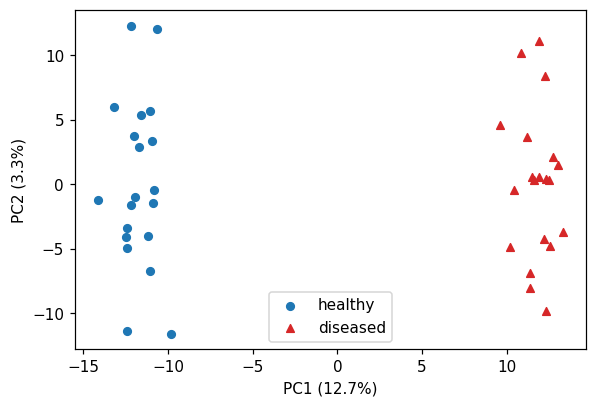

In [14]:
pg = PCA().fit(X - X.mean(0))
Zg = pg.transform(X - X.mean(0))
print('PVE of first 5 components:', np.round(pg.explained_variance_ratio_[:5], 4))
print('first 20 components carry %.0f%%' % (100 * pg.explained_variance_ratio_[:20].sum()))
print('PC1 group means: healthy %.2f   diseased %.2f' % (Zg[:20, 0].mean(), Zg[20:, 0].mean()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Zg[:20, 0], Zg[:20, 1], s=25, label='healthy')
ax.scatter(Zg[20:, 0], Zg[20:, 1], s=25, marker='^', color='C3', label='diseased')
ax.set(xlabel='PC1 (12.7%)', ylabel='PC2 (3.3%)'); ax.legend(); plt.show()

**Reading the output.** PC1 explains only $12.7\%$ of the variance yet separates the two groups
completely (group means $-11.75$ and $+11.75$). With $p \gg n$ a modest PVE is not a failure: the
variance is spread thinly over 39 components, and the interesting direction need not be the
biggest one.

In [15]:
# Optional: NCI60 ships only with the ISLP package, so this block is guarded.
if HAVE_ISLP:
    nci = load_data('NCI60')
    Xn = StandardScaler().fit_transform(nci['data'])
    kmn = KMeans(n_clusters=4, n_init=20, random_state=0).fit(Xn)
    print(pd.crosstab(nci['labels'].squeeze(), kmn.labels_))
else:
    print('NCI60 ships only with the ISLP package; the Ch12Ex13 thread above covers the '
          'same p >> n lesson with a bundled data set.')

col_0        0  1  2  3
label                  
BREAST       0  3  2  2
CNS          0  5  0  0
COLON        0  0  7  0
K562A-repro  1  0  0  0
K562B-repro  1  0  0  0
LEUKEMIA     6  0  0  0
MCF7A-repro  0  0  1  0
MCF7D-repro  0  0  1  0
MELANOMA     0  1  0  7
NSCLC        1  4  4  0
OVARIAN      0  3  3  0
PROSTATE     0  1  1  0
RENAL        0  9  0  0
UNKNOWN      0  1  0  0


## 5. Practical issues: outliers, and clusters in pure noise

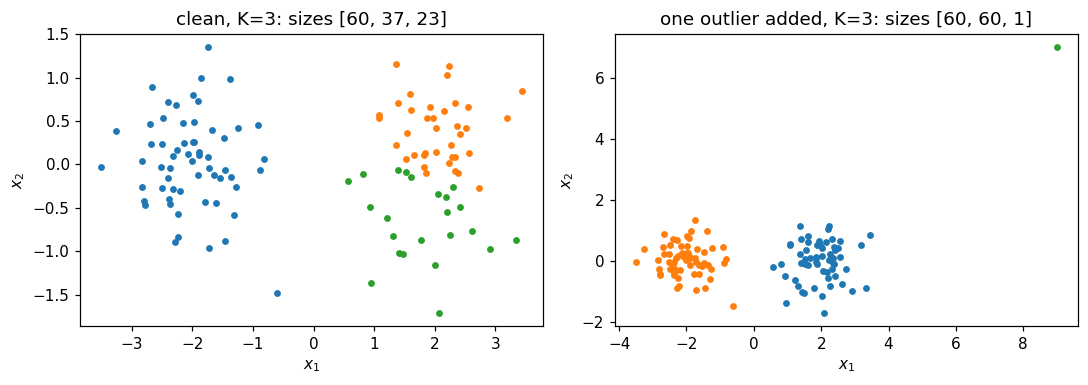

In [16]:
r0 = np.random.default_rng(2024)                       # same seed as the slide figure
Xg = np.vstack([r0.normal([-2, 0], 0.6, (60, 2)), r0.normal([2, 0], 0.6, (60, 2))])
Xo = np.vstack([Xg, [[9.0, 7.0]]])                     # one far-away point

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, D, name in [(axes[0], Xg, 'clean'), (axes[1], Xo, 'one outlier added')]:
    km = KMeans(n_clusters=3, n_init=50, random_state=0).fit(D)
    for k in range(3):
        ax.scatter(D[km.labels_ == k, 0], D[km.labels_ == k, 1], s=12)
    ax.set(title=f'{name}, K=3: sizes {np.bincount(km.labels_).tolist()}',
           xlabel='$x_1$', ylabel='$x_2$')
plt.tight_layout(); plt.show()

**Reading the output.** Two real groups of 60. Forced to $K=3$ on clean data, $K$-means splits the
right-hand group into $37+23$. Add a single point at $(9,7)$ and it takes a whole cluster to
itself: sizes $(60,60,1)$. Squared distance makes one far point worth hundreds of ordinary ones.
A near-singleton cluster is a data-quality alarm, not a discovery.

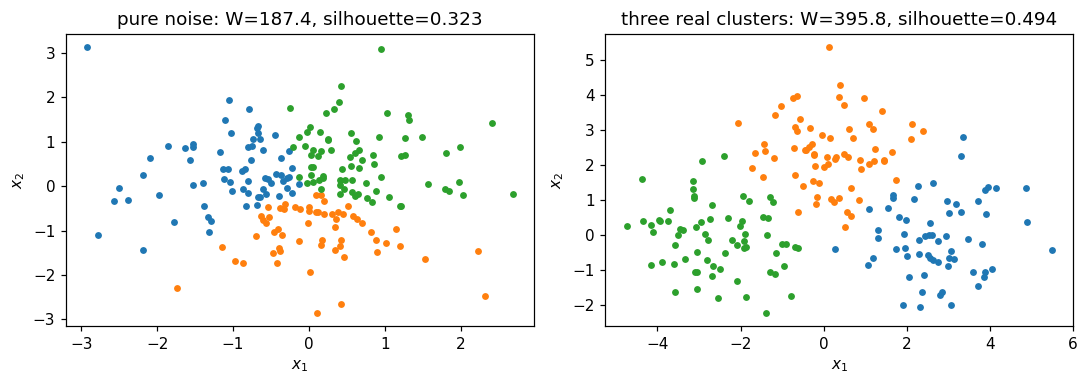

In [17]:
from sklearn.metrics import silhouette_score

rng2  = np.random.default_rng(2024)
noise = rng2.normal(size=(200, 2))                     # ONE Gaussian: no clusters
mu    = np.array([[-2.5, 0.], [2.5, 0.], [0., 2.5]])
lab   = rng2.integers(0, 3, 200)
real  = mu[lab] + rng2.normal(size=(200, 2))           # three separated clusters

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, D, name in [(axes[0], noise, 'pure noise'), (axes[1], real, 'three real clusters')]:
    km = KMeans(n_clusters=3, n_init=50, random_state=0).fit(D)
    for k in range(3):
        ax.scatter(D[km.labels_ == k, 0], D[km.labels_ == k, 1], s=12)
    ax.set(title=f'{name}: W={km.inertia_:.1f}, '
                 f'silhouette={silhouette_score(D, km.labels_):.3f}',
           xlabel='$x_1$', ylabel='$x_2$')
plt.tight_layout(); plt.show()

**Reading the output.** The left panel is 200 draws from a *single* two-dimensional Gaussian. There
are no clusters, and $K$-means returns three tidy contiguous groups anyway, with $W=187.4$ (down
from $398.0$ at $K=1$, so $53\%$ "explained") and a silhouette of $0.323$ against $0.494$ for the
genuinely separated data on the right. No threshold on either number separates the two panels
reliably — Extended Exercise 12.2 below makes that precise.

In [18]:
# Stability: re-fit K=3 on 200 bootstrap resamples and compare with the full-data fit.
boot = np.random.default_rng(2024)
aris = []
for _ in range(200):
    idx = boot.integers(0, 50, 50)
    kmb = KMeans(n_clusters=3, n_init=50, random_state=0).fit(Xs[idx])
    aris.append(adjusted_rand_score(km3.labels_, kmb.predict(Xs)))
print('bootstrap stability of the K=3 partition:'
      f'  mean ARI {np.mean(aris):.3f}   median {np.median(aris):.3f}')

bootstrap stability of the K=3 partition:  mean ARI 0.682   median 0.773


**Reading the output.** Mean adjusted Rand index $0.68$ (median $0.77$) — the number the deck
quotes on *How to report a clustering honestly*. Reproducible enough to report, and far from the
$1.0$ that "three types of state" would imply. Stability is the closest thing to validation that
unsupervised learning offers, and it is not the same thing: noise clusters stably too.

## Lecture exercises — worked Python solutions

These are the **exercises from the lecture slides**, solved step by step; run them cell by cell.
Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and
on Colab. Conceptual and pencil-and-paper exercises are answered in markdown; every
`[Python]`-tagged one is answered in code with the same seeds as the slides.

### Exercise 12.1 — Why there is no test error [Concept]

**Task (from the slides).** A colleague clusters 80% of the customers, assigns the held-out 20% to
their nearest centroid, finds "zero assignment error", and calls the clustering validated.

**Answer.**

1. **The argument is circular.** "Nearest centroid" *defines* the held-out label; there is no
   independent label for it to disagree with, so the error is zero by construction. A test set
   works in Chapter 2 only because the held-out $y_i$ was fixed before the model existed.
2. **What you can compute: stability.** Cluster two halves separately, or bootstrap, and measure
   agreement (adjusted Rand index, or the share of pairs that stay together). High stability shows
   the partition is *reproducible*, not that it is *real* — pure noise clusters very stably,
   because the split follows the noise's own geometry.
3. **External evidence.** Turn it into a supervised question: a campaign on two segments with
   matched controls, or a check that segment membership improves prediction of an outcome that was
   never used to build it.

*Common mistake:* calling the within-cluster sum of squares an "error". It is the objective the
algorithm minimises, so it always improves with more clusters.

### Exercise 12.2 — PCA from a $2\times2$ correlation matrix [Math]

**Task (from the slides).** $\mathbf{R}=\begin{pmatrix}1 & 0.8\\ 0.8 & 1\end{pmatrix}$ (the real
Murder–Assault correlation, $0.8019$, to two decimals). Find the eigenvalues and loading vectors,
the PVEs, the scores of $(x_1,x_2)=(1.5,1.0)$, and say what a sign flip changes.

**Answer.**

1. $\det(\mathbf{R}-\lambda I)=(1-\lambda)^2-r^2=0 \Rightarrow \lambda = 1\pm r$, so
   $\lambda_1=1.8$ and $\lambda_2=0.2$. Substituting $\lambda_1$ gives $\phi_1=\phi_2$, hence
   $\phi_1=\tfrac{1}{\sqrt2}(1,1)^\top=(0.707,0.707)^\top$ and
   $\phi_2=\tfrac{1}{\sqrt2}(1,-1)^\top$.
2. Total variance $=\lambda_1+\lambda_2=2=p$, so $\mathrm{PVE}_1=1.8/2=90\%$ and
   $\mathrm{PVE}_2=10\%$.
3. $z_1 = 0.707(1.5)+0.707(1.0)=1.768$ and $z_2 = 0.707(1.5)-0.707(1.0)=0.354$.
4. Replacing $\phi_1$ by $-\phi_1$ leaves $\lambda_1$, $\mathrm{PVE}_1$ and every distance
   unchanged, and flips every PC1 score: $z_1=-1.768$. Same analysis, mirrored picture.

In [19]:
# Numerical check of Exercise 12.2.
R = np.array([[1.0, 0.8], [0.8, 1.0]])
w, v = np.linalg.eigh(R)
print('eigenvalues', w[::-1].round(4), ' PVE', (w[::-1] / w.sum()).round(3))
print('loading vectors\n', v[:, ::-1].round(4))
print('scores of (1.5, 1.0):', (np.array([1.5, 1.0]) @ v[:, ::-1]).round(3))
print('real Murder-Assault correlation:', round(USA['Murder'].corr(USA['Assault']), 4))

eigenvalues [1.8 0.2]  PVE [0.9 0.1]
loading vectors
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]
scores of (1.5, 1.0): [ 1.768 -0.354]
real Murder-Assault correlation: 0.8019


### Exercise 12.3 — Scaled vs unscaled PCA on USArrests [Python]

**Task (from the slides).** Run PCA on the standardised and on the centred-but-unscaled data;
report the four PVEs and the PC1 loadings for each; explain the difference from the raw variances
and say which analysis goes in a report.

In [20]:
USA = load('USArrests', index_col=0)                          # 50 states x 4 features
print('raw variances:', USA.var().round(1).to_dict())

for tag, X in [('scaled  ', StandardScaler().fit_transform(USA)),
               ('unscaled', (USA - USA.mean()).values)]:      # centred only
    p = PCA().fit(X)
    print(tag, 'PVE', np.round(p.explained_variance_ratio_, 4))
    print(tag, 'PC1', pd.Series(p.components_[0].round(3), index=USA.columns).to_dict())
# Expected: scaled PVE [0.6201 0.2474 0.0891 0.0434]; unscaled [0.9655 0.0278 0.0058 0.0009]

raw variances: {'Murder': 19.0, 'Assault': 6945.2, 'UrbanPop': 209.5, 'Rape': 87.7}
scaled   PVE [0.6201 0.2474 0.0891 0.0434]
scaled   PC1 {'Murder': 0.536, 'Assault': 0.583, 'UrbanPop': 0.278, 'Rape': 0.543}
unscaled PVE [9.655e-01 2.780e-02 5.800e-03 8.000e-04]
unscaled PC1 {'Murder': 0.042, 'Assault': 0.995, 'UrbanPop': 0.046, 'Rape': 0.075}


**Reading the output.** Standardised, PC1 takes $62.0\%$ and loads on all four variables
$(0.536,0.583,0.278,0.543)$. Unscaled, PC1 takes $96.6\%$ and is $(0.042,0.995,0.046,0.075)$ — i.e.
`Assault` alone, because `Assault` carries 366 times the variance of `Murder` purely from how
common assaults are. The **standardised** analysis is what goes in the report, and the methods
section should say that the features were standardised and why. Reporting "PC1 explains 96.6%" is
quoting the largest available number and the least informative one.

### Exercise 12.4 — Two local optima on four points [Math]

**Task (from the slides).** Four points at the corners of a rectangle, $x_1=(0,0)$, $x_2=(0,1)$,
$x_3=(4,0)$, $x_4=(4,1)$, and $K=2$.

**Answer.**

1. **Vertical split** $\{x_1,x_2\},\{x_3,x_4\}$: centroids $(0,0.5)$ and $(4,0.5)$, every point
   $0.5$ away, so $W = 4\times 0.5^2 = 1.0$.
2. **Horizontal split** $\{x_1,x_3\},\{x_2,x_4\}$: centroids $(2,0)$ and $(2,1)$, every point $2$
   away in $x_1$, so $W = 4\times 2^2 = 16.0$.
3. **The horizontal split is stable.** For $x_1=(0,0)$: $\|x_1-(2,0)\|^2 = 4$ against
   $\|x_1-(2,1)\|^2 = 5$, so it stays where it is; by symmetry so does every other point, and the
   centroids do not move. The algorithm terminates here and reports $W=16$ — sixteen times the
   optimum, with no warning.
4. A single run of $K$-means can therefore return an arbitrarily bad partition: the stopping rule
   ("no point wants to move") is satisfied at both $W=1$ and $W=16$. Only comparing several random
   starts and keeping the lowest $W$ protects you — that is what `n_init` does.

In [21]:
# Numerical check of Exercise 12.4.
Xr = np.array([[0., 0.], [0., 1.], [4., 0.], [4., 1.]])
for init, name in [(np.array([[0., 0.5], [4., 0.5]]), 'vertical  '),
                   (np.array([[2., 0.], [2., 1.]]),  'horizontal')]:
    km = KMeans(n_clusters=2, init=init, n_init=1).fit(Xr)
    print(name, 'init -> labels', km.labels_.tolist(), ' W =', round(km.inertia_, 3))
print('n_init=20  ->  W =', round(KMeans(n_clusters=2, n_init=20, random_state=0)
                                  .fit(Xr).inertia_, 3))

vertical   init -> labels [0, 0, 1, 1]  W = 1.0
horizontal init -> labels [0, 1, 0, 1]  W = 16.0
n_init=20  ->  W = 1.0


### Exercise 12.5 — Reading a dendrogram [Concept]

**Task (from the slides).** Fusion heights: $\{A,B\}$ at $0.4$; $\{C,D\}$ at $0.6$; $\{A,B\}$ with
$E$ at $1.5$; $\{A,B,E\}$ with $\{C,D\}$ at $2.8$.

**Answer.**

1. $A$ and $B$ fuse lowest ($0.4$) and are the most similar pair. The last individual leaf to join
   anything is $E$, at $1.5$, so $E$ is the most isolated single observation.
2. Cuts: at $0.5 \to \{A,B\},\{C\},\{D\},\{E\}$ ($K=4$); at $1.0 \to \{A,B\},\{C,D\},\{E\}$
   ($K=3$); at $2.0 \to \{A,B,E\},\{C,D\}$ ($K=2$); at $3.0 \to$ one cluster.
3. $E$ appearing next to $C$ tells you **nothing**: horizontal order is a drawing choice, and a
   tree on $n$ leaves has $2^{n-1}$ equally valid drawings. $E$ and $C$ first share a cluster only
   at $2.8$, the tallest fusion, so they are among the *least* similar pairs.
4. "Cut at the biggest vertical gap" uses the same data that produced the tree, so the tree cannot
   contradict it; every data set, structured or not, has a largest gap. It is a way of *proposing*
   $K$, never evidence that $K$ clusters exist.

### Exercise 12.6 — Complete vs single linkage by hand [Math]

**Task (from the slides).** Dissimilarities $d(1,2)=0.30$, $d(1,3)=0.40$, $d(1,4)=0.70$,
$d(2,3)=0.50$, $d(2,4)=0.80$, $d(3,4)=0.45$.

**Answer.**

**Complete linkage.** Fuse $\{1,2\}$ at $\mathbf{0.30}$. Update with the *maximum*:
$d(\{1,2\},3)=\max(0.40,0.50)=0.50$, $d(\{1,2\},4)=\max(0.70,0.80)=0.80$, $d(3,4)=0.45$. The
smallest is $0.45$, so fuse $\{3,4\}$ at $\mathbf{0.45}$; the root follows at
$\max(0.40,0.50,0.70,0.80)=\mathbf{0.80}$. Two clusters: $\{1,2\}$ and $\{3,4\}$.

**Single linkage.** Same first fusion at $\mathbf{0.30}$. Update with the *minimum*:
$d(\{1,2\},3)=0.40$, $d(\{1,2\},4)=0.70$, $d(3,4)=0.45$. Now $3$ joins $\{1,2\}$ at
$\mathbf{0.40}$, before $3$ and $4$ ever meet, and $4$ joins at
$\min(0.70,0.80,0.45)=\mathbf{0.45}$. Two clusters: $\{1,2,3\}$ and $\{4\}$.

**Why.** Complete judged $\{1,2\}$ against $3$ by their worst pair ($0.50$), which let $3$ and $4$
pair up first; single judged them by their best pair ($0.40$) and chained $3$ on, leaving $4$
alone. Single linkage's heights are also systematically lower, so its tree looks flatter.

In [22]:
# Numerical check of Exercise 12.6 (scipy wants the condensed upper triangle).
d = np.array([0.30, 0.40, 0.70, 0.50, 0.80, 0.45])     # (1,2) (1,3) (1,4) (2,3) (2,4) (3,4)
for m in ('complete', 'single'):
    Zl = linkage(d, method=m)
    print(m, 'fusion heights', Zl[:, 2].round(2).tolist(),
          ' cut into 2 ->', fcluster(Zl, 2, criterion='maxclust').tolist())

complete fusion heights [0.3, 0.45, 0.8]  cut into 2 -> [1, 1, 2, 2]
single fusion heights [0.3, 0.4, 0.45]  cut into 2 -> [1, 1, 1, 2]


### Extended Exercise 12.1 — How bad is the local-optimum problem? [Python]

**Task (from the slides).**

1. For $K=4$, run $K$-means with `n_init=1` for seeds $0,\dots,19$ and collect the objective.
2. Report the number of distinct local optima, the best and worst objective and the gap.
3. Compare with `n_init=50`, and repeat at $K=8$.
4. State the reporting rule these numbers imply.

In [23]:
Xs = StandardScaler().fit_transform(load('USArrests', index_col=0))

for K in (4, 8):
    runs = [KMeans(n_clusters=K, n_init=1, random_state=s).fit(Xs) for s in range(20)]
    w    = np.array([r.inertia_ for r in runs])          # the objective, once per seed
    best = KMeans(n_clusters=K, n_init=50, random_state=0).fit(Xs).inertia_
    print(f'K={K}: {len(np.unique(w.round(3)))} optima  min={w.min():.3f}  '
          f'max={w.max():.3f}  gap={100 * (w.max() / w.min() - 1):.1f}%  '
          f'n_init=50 -> {best:.3f}')
    print('  best / worst sizes', sorted(np.bincount(runs[w.argmin()].labels_).tolist()),
          sorted(np.bincount(runs[w.argmax()].labels_).tolist()))
# Expected: K=4 -> 9 optima, 57.554 .. 77.856, gap 35.3% ; K=8 -> 20 optima, gap 12.1%

K=4: 9 optima  min=57.554  max=77.856  gap=35.3%  n_init=50 -> 57.554
  best / worst sizes [8, 13, 13, 16] [1, 8, 13, 28]
K=8: 20 optima  min=36.551  max=40.965  gap=12.1%  n_init=50 -> 34.636
  best / worst sizes [1, 3, 3, 4, 9, 9, 10, 11] [3, 3, 4, 4, 6, 6, 9, 15]


**Reading the output.** At $K=4$ twenty single starts land on **nine** different local optima and
the worst is $35.3\%$ above the best; the failure is structural, not rounding — the worst run
returns sizes $(1,8,13,28)$ against $(8,13,13,16)$ for the best. At $K=8$ all twenty runs give
twenty *different* values and none of them reaches the `n_init=50` value of $34.636$: more
clusters means a rougher objective surface, exactly where one run is least trustworthy.

**The reporting rule.** Every reported clustering states $K$, the dissimilarity, the scaling,
`n_init` ($\ge 20$), the seed and the achieved objective. Two runs whose $W$ differs are not two
opinions; one of them is simply worse.

### Extended Exercise 12.2 — Clustering pure noise [Python]

**Task (from the slides).** Simulate 200 points from one bivariate normal and 200 from three
separated clusters; for $K=1,\dots,8$ record $W(K)$ and the mean silhouette; report $W(3)/W(1)$,
the silhouette at $K=3$ and where the silhouette peaks on the noise; then propose a diagnostic that
would have flagged it.

In [24]:
rng   = np.random.default_rng(2024)         # same seed as the slide figure
noise = rng.normal(size=(200, 2))           # ONE Gaussian: no clusters at all
mu    = np.array([[-2.5, 0.], [2.5, 0.], [0., 2.5]])
lab   = rng.integers(0, 3, 200)             # true group of each point
real  = mu[lab] + rng.normal(size=(200, 2))    # three separated clusters
km    = lambda X, K: KMeans(n_clusters=K, n_init=50, random_state=0).fit(X)

for name, X in [('noise', noise), ('real ', real)]:
    W    = {K: km(X, K).inertia_ for K in range(1, 9)}
    sil  = {K: silhouette_score(X, km(X, K).labels_) for K in range(2, 9)}
    peak = max(sil, key=sil.get)            # K with the best silhouette
    print(f'{name} W(3)/W(1)={W[3] / W[1]:.3f} sil(3)={sil[3]:.3f} '
          f'peak K={peak} ({sil[peak]:.3f})')
    print('      W:', {k: round(v, 1) for k, v in W.items()})
# Expected: noise 0.471 / 0.323 / peak K=8 ; real 0.248 / 0.494 / peak K=3

noise W(3)/W(1)=0.471 sil(3)=0.323 peak K=8 (0.337)
      W: {1: 398.0, 2: 275.5, 3: 187.4, 4: 154.1, 5: 126.7, 6: 105.4, 7: 92.7, 8: 79.2}


real  W(3)/W(1)=0.248 sil(3)=0.494 peak K=3 (0.494)
      W: {1: 1593.3, 2: 786.1, 3: 395.8, 4: 333.0, 5: 273.5, 6: 229.6, 7: 195.2, 8: 170.1}


**Reading the output.** Three clusters of nothing still cut the objective by $52.9\%$
($398.0 \to 187.4$) and score a silhouette of $0.323$ — a value many practitioners would call
"reasonable structure". On the noise the silhouette *rises* again to $0.337$ at $K=8$: it never
says "stop". Only the comparison with the real data ($0.494$, peaking exactly at $K=3$) exposes
it, and in an application there is no real data to compare with.

**A diagnostic that works.** Compare the observed $\log W(K)$ with its distribution under a
simulated *no-cluster* reference (uniform or Gaussian over the same range) — the gap statistic, or
any permutation version of it. The cost is that you must specify the null, it is far more
computation, and it has power only for well-separated clusters. There is no free validation here.

### Extended Exercise 12.3 — A full workflow on gene expression [Python]

**Task (from the slides).** Cluster the 40 samples of `Ch12Ex13` with complete, average and single
linkage under Euclidean and correlation-based distance; score all six partitions against the true
labels; run PCA on the samples; and count how many of the 1000 genes survive a Bonferroni
threshold at $0.05/1000$.

In [25]:
from scipy import stats

G = load('Ch12Ex13', header=None).values   # 1000 genes x 40 samples
X = G.T                                    # cluster the SAMPLES: 40 x 1000
truth = np.array([0] * 20 + [1] * 20)      # for SCORING only, never for fitting

for nm, arg in [('eucl', X), ('1-r', squareform(1 - np.corrcoef(X), checks=False))]:
    for m in ('complete', 'average', 'single'):
        lab = fcluster(linkage(arg, method=m), 2, criterion='maxclust')
        print(nm, m, np.bincount(lab)[1:], round(adjusted_rand_score(truth, lab), 3))

p = PCA().fit(X - X.mean(0)); Z = p.transform(X - X.mean(0))   # PCA on the samples
print('PVE1', round(p.explained_variance_ratio_[0], 3),
      ' PC1 group means', round(Z[:20, 0].mean(), 2), round(Z[20:, 0].mean(), 2))
t, pv = stats.ttest_ind(G[:, 20:], G[:, :20], axis=1)   # 1000 two-sample t-tests
print((pv < 0.05).sum(), (pv < 0.05 / 1000).sum())      # 159 nominal, 105 Bonferroni
print('share of the top-100 genes lying in 501-1000:',
      ((np.argsort(pv)[:100] + 1) > 500).mean())

eucl complete [20 20] 1.0
eucl average [20 20] 1.0
eucl single [20 20] 1.0
1-r complete [30 10] 0.235
1-r average [31  9] 0.188
1-r single [39  1] 0.0
PVE1 0.127  PC1 group means -11.75 11.75
159 105
share of the top-100 genes lying in 501-1000: 0.91


**Reading the output.** Euclidean distance recovers the truth under all three linkages
(ARI $=1.000$); $1-r$ under none ($0.235$, $0.188$, $0.000$). The dissimilarity mattered
enormously, the linkage barely at all, because the diseased group differs by a level shift in
genes 501–1000 and $1-r$ discards levels by construction.

PC1 explains $12.7\%$ and still separates the groups completely (means $-11.75$ and $+11.75$).

Finally the bridge to Chapter 13: $159$ genes have $p<0.05$, but about $50$ are expected under the
global null, so that list is not a finding. **105** survive Bonferroni at $5\times10^{-5}$, and
$91$ of the 100 smallest $p$-values fall in genes 501–1000 — the block that was constructed to
differ. That is the only part of this analysis with a guarantee attached.

*Common mistake:* using `truth` anywhere before the scoring step. If the labels are available you
have a supervised problem; clustering is what you do when they are not. And note that testing the
very genes that defined the clusters would be post-selection inference — the $p$-values would be
optimistic even after Bonferroni.

## 6. Exercises
1. Use the silhouette score to pick $K$ on `USArrests`, and then argue against your own answer.
2. Apply complete linkage and compare with Ward, using the adjusted Rand index.
3. Plot the proportion of variance explained for the first 10 PCs of the gene-expression data.
4. Implement the matrix-completion algorithm (iterative PCA imputation) on a data set with random
   missing entries.